In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
symbol = 'MSFT'
data = yf.download(symbol, start='2021-04-01', end='2023-05-01')
# Drop extra columns for paucity
data.drop(['Open', 'High', 'Low', 'Volume','Close'], inplace=True, axis=1)

print(data.head())

[*********************100%%**********************]  1 of 1 completed

             Adj Close
Date                  
2021-04-01  235.693481
2021-04-05  242.228928
2021-04-06  241.052124
2021-04-07  243.036087
2021-04-08  246.294067


In [5]:
def calcRSI(data, P=14):
  data['diff_close'] = data['Adj Close'] - data['Adj Close'].shift(1)
  data['gain'] = np.where(data['diff_close']>0, 
    data['diff_close'], 0)
  data['loss'] = np.where(data['diff_close']<0,
    np.abs(data['diff_close']), 0)
  data[['init_avg_gain', 'init_avg_loss']] = data[
    ['gain', 'loss']].rolling(P).mean()
  avg_gain = np.zeros(len(data))
  avg_loss = np.zeros(len(data))
  
  for i, _row in enumerate(data.iterrows()):
    row = _row[1]
    if i < P - 1:
      last_row = row.copy()
      continue
    elif i == P-1:
      avg_gain[i] += row['init_avg_gain']
      avg_loss[i] += row['init_avg_loss']
    else:
      avg_gain[i] += ((P - 1) * avg_gain[i-1] + row['gain']) / P
      avg_loss[i] += ((P - 1) * avg_loss[i-1] + row['loss']) / P
    last_row = row.copy()
  data['avg_gain'] = avg_gain
  data['avg_loss'] = avg_loss
  data['RS'] = data['avg_gain'] / data['avg_loss']
  data['RSI'] = 100 - 100 / (1 + data['RS'])
  return data

In [18]:
# Standard Mean Reversion
def RSIReversionStrategy(data, P=14, long_level=30, short_level=70,
  centerline=50, shorts=True):
  '''
  Goes long when RSI < long level, sells when the value crosses the
  centerline.
  Goes short when RSI > short level, covers when it crosses the
  centerline.
  '''
  df = calcRSI(data, P=P)
  df['position'] = np.nan
  df['position'] = np.where(df['RSI']<long_level, 1, df['position'])
  if shorts:
    df['position'] = np.where(df['RSI']>short_level, -1,
      df['position'])
  if centerline is not None:
    # Exit when RSI crosses sell_level
    _sell_level = df['RSI'] - centerline
    df['cross_sell_level'] = _sell_level.shift(1) / _sell_level
    df['position'] = np.where(df['cross_sell_level']<0, 0,   
      df['position'])
  else:
    df['position'] = np.where(df['RSI']>=short_level, 0,  
      df['position'])
  
  df['position'] = df['position'].ffill().fillna(0)
  
  return calcReturns(df)
def calcReturns(df):
  # Helper function to avoid repeating too much code
  df['returns'] = df['Adj Close'] / df['Adj Close'].shift(1)
  df['log_returns'] = np.log(df['returns'])
  df['strat_returns'] = df['position'].shift(1) * df['returns']
  df['strat_log_returns'] = df['position'].shift(1) * df['log_returns']
  df['cum_returns'] = np.exp(df['log_returns'].cumsum()) - 1
  df['strat_cum_returns'] = np.exp(
    df['strat_log_returns'].cumsum()) - 1
  df['peak'] = df['cum_returns'].cummax()
  df['strat_peak'] = df['strat_cum_returns'].cummax()
  return df

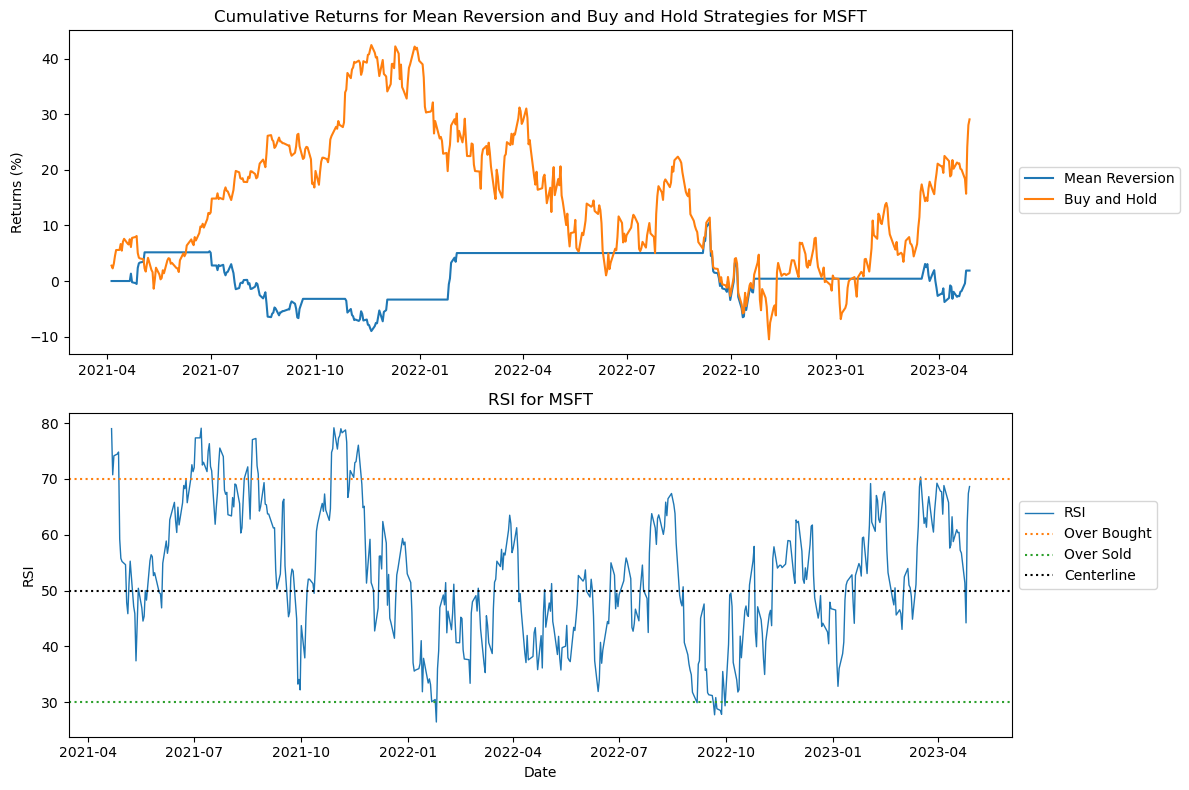

In [19]:
df_rev = RSIReversionStrategy(data.copy())
# Plot results
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(2, figsize=(12, 8))
ax[0].plot(df_rev['strat_cum_returns']*100, label='Mean Reversion')
ax[0].plot(df_rev['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for Mean Reversion and' +
  f' Buy and Hold Strategies for {ticker}')
ax[0].legend(bbox_to_anchor=[1, 0.6])
ax[1].plot(df_rev['RSI'], label='RSI', linewidth=1)
ax[1].axhline(70, label='Over Bought', color=colors[1], linestyle=':')
ax[1].axhline(30, label='Over Sold', color=colors[2], linestyle=':')
ax[1].axhline(50, label='Centerline', color='k', linestyle=':')
ax[1].set_ylabel('RSI')
ax[1].set_xlabel('Date')
ax[1].set_title(f'RSI for {ticker}')
ax[1].legend(bbox_to_anchor=[1, 0.75])
plt.tight_layout()
plt.show()


In [21]:
def getStratStats(log_returns: pd.Series, 
  risk_free_rate: float = 0.02):
  stats = {}
  # Total Returns
  stats['tot_returns'] = np.exp(log_returns.sum()) - 1
  # Mean Annual Returns
  stats['annual_returns'] = np.exp(log_returns.mean() * 252) - 1
  # Annual Volatility
  stats['annual_volatility'] = log_returns.std() * np.sqrt(252)
  # Sharpe Ratio
  stats['sharpe_ratio'] = (stats['annual_returns'] - 
    risk_free_rate) / stats['annual_volatility']
  # Max Drawdown
  cum_returns = log_returns.cumsum() - 1
  peak = cum_returns.cummax()
  drawdown = peak - cum_returns
  stats['max_drawdown'] = drawdown.max()
  # Max Drawdown Duration
  strat_dd = drawdown[drawdown==0]
  strat_dd_diff = strat_dd.index[1:] - strat_dd.index[:-1]
  strat_dd_days = strat_dd_diff.map(lambda x: x.days).values
  strat_dd_days = np.hstack([strat_dd_days,
    (drawdown.index[-1] - strat_dd.index[-1]).days])
  stats['max_drawdown_duration'] = strat_dd_days.max()
  return stats

In [20]:
def calcReturns(df):
  # Helper function to avoid repeating too much code
  df['returns'] = df['Adj Close'] / df['Adj Close'].shift(1)
  df['log_returns'] = np.log(df['returns'])
  df['strat_returns'] = df['position'].shift(1) * df['returns']
  df['strat_log_returns'] = df['position'].shift(1) *df['log_returns']
  df['cum_returns'] = np.exp(df['log_returns'].cumsum()) - 1
  df['strat_cum_returns'] = np.exp(
    df['strat_log_returns'].cumsum()) - 1
  df['peak'] = df['cum_returns'].cummax()
  df['strat_peak'] = df['strat_cum_returns'].cummax()
  return df

In [23]:
# RSI2
def RSI2Strategy(data, P=2, SMA1=200, SMA2=5, long_level=10,
  short_level=90):
  df = calcRSI(data, P=P)
  df['SMA1'] = df['Adj Close'].rolling(SMA1).mean()
  df['SMA2'] = df['Adj Close'].rolling(SMA2).mean()
  position = np.zeros(df.shape[0])
  position[:] = np.nan
  # Enter long positions
  position = np.where(
    (df['RSI']<long_level) & (df['Adj Close']>df['SMA1']), 1, position)
  # Enter short positions
  position = np.where(
    (df['RSI']>short_level) & (df['Adj Close']<df['SMA1']), 
      -1, position)
  # Loop to add exits
  for i, _row in enumerate(df.iterrows()):
    row = _row[1]
    if np.isnan(row['SMA1']):
      position[i] = 0
      continue
    # Exit positions based on SMA2, else hold
    if position[i-1] == 1:
      if row['Adj Close'] > row['SMA2']:
        position[i] = 0
      else:
        position[i] = 1
    elif position[i-1] == -1:
      if row['Adj Close'] < row['SMA2']:
        position[i] = 0
      else:
        position[i] = -1
  df['position'] = position
  df['position'] = df['position'].fillna(0)
  
  return calcReturns(df)

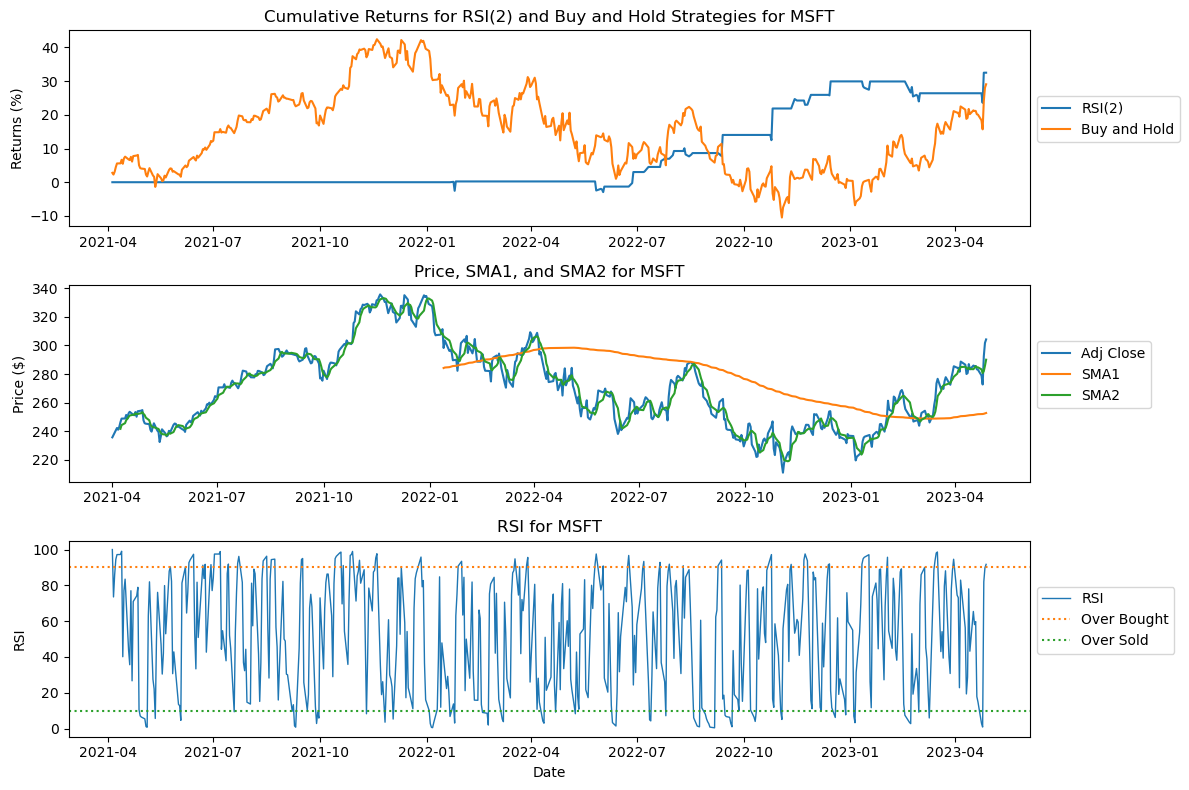

In [24]:
df_rsi2 = RSI2Strategy(data.copy())
# Plot results
fig, ax = plt.subplots(3, figsize=(12, 8))
ax[0].plot(df_rsi2['strat_cum_returns']*100, label='RSI(2)')
ax[0].plot(df_rsi2['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for RSI(2) and' +
  f' Buy and Hold Strategies for {symbol}')
ax[0].legend(bbox_to_anchor=[1, 0.7])
ax[1].plot(df_rsi2['Adj Close'], label='Adj Close')
ax[1].plot(df_rsi2['SMA1'], label='SMA1')
ax[1].plot(df_rsi2['SMA2'], label='SMA2')
ax[1].set_ylabel('Price ($)')
ax[1].set_title(f'Price, SMA1, and SMA2 for {symbol}')
ax[1].legend(bbox_to_anchor=[1, 0.75])
ax[2].plot(df_rsi2['RSI'], label='RSI', linewidth=1)
ax[2].axhline(90, label='Over Bought', color=colors[1], linestyle=':')
ax[2].axhline(10, label='Over Sold', color=colors[2], linestyle=':')
ax[2].set_ylabel('RSI')
ax[2].set_xlabel('Date')
ax[2].set_title(f'RSI for {symbol}')
ax[2].legend(bbox_to_anchor=[1, 0.8])
plt.tight_layout()
plt.show()

In [25]:
# Trend Strategy
def RSITrendStrategy(data, P=14, sma1=5, sma2=20, 
  centerline=50, shorts=True):
  '''
  Buy when RSI crosses above centerline and when SMA1>SMA2.
  Sell if one of the conditions are no longer met.
  Short if RSI is below centerline and SMA1<SMA2
  '''
  df = calcRSI(data, P=P)
  df['SMA1'] = df['Adj Close'].rolling(sma1).mean()
  df['SMA2'] = df['Adj Close'].rolling(sma2).mean()
  df['position'] = np.nan
  df['position'] = np.where(
    (df['RSI']>centerline) & (df['SMA1']>df['SMA2']), 1,
    df['position'])
  df['position'] = np.where(
    (df['RSI']<centerline) & (df['SMA1']>df['SMA2']), 0,
    df['position'])
  df['position'] = np.where(
    (df['RSI']>centerline) & (df['SMA1']<df['SMA2']), 0, 
    df['position'])
  
  if shorts:
    df['position'] = np.where(
      (df['RSI']>centerline) & (df['SMA1']>df['SMA2']), -1,
      df['position'])
  else:
    df['position'] = np.where(
      (df['RSI']>centerline) & (df['SMA1']>df['SMA2']), 0,   
      df['position'])
  df['position'] = df['position'].ffill().fillna(0)
  return calcReturns(df)

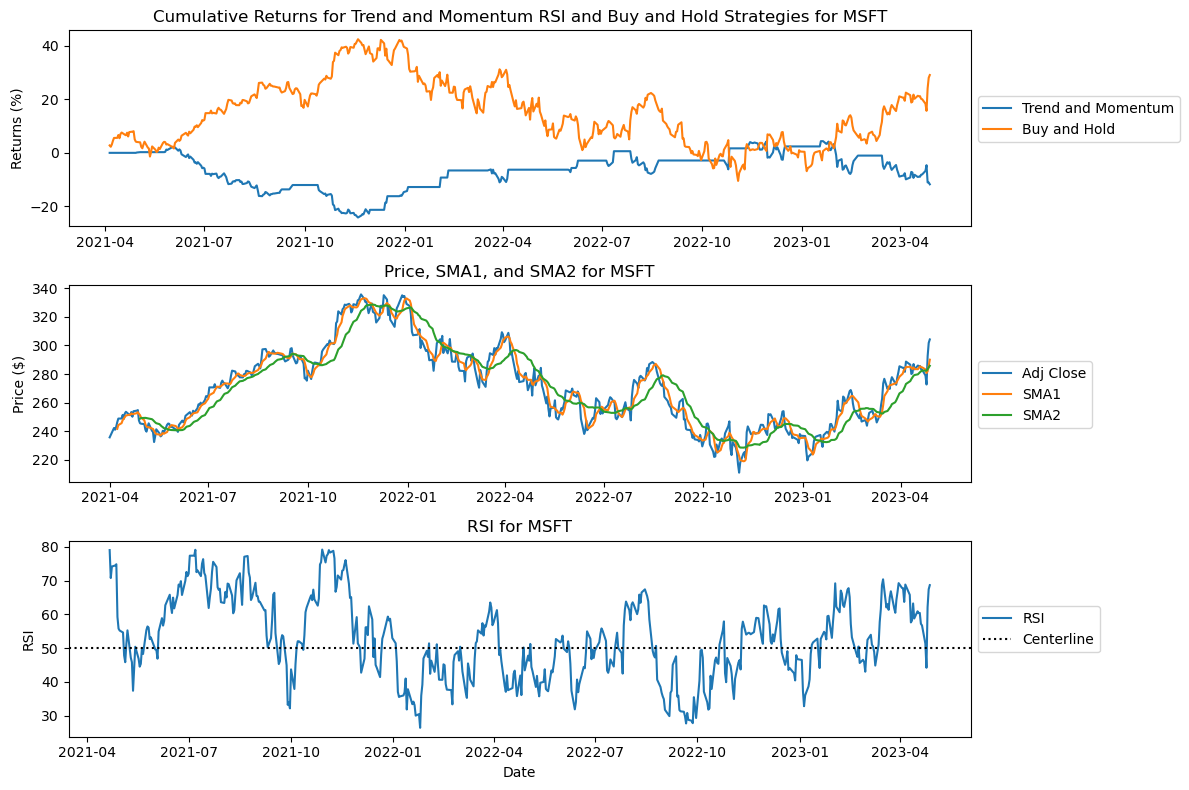

In [26]:
df_trend = RSITrendStrategy(data.copy())
# Plot results
fig, ax = plt.subplots(3, figsize=(12, 8))
ax[0].plot(df_trend['strat_cum_returns']*100, 
  label='Trend and Momentum')
ax[0].plot(df_trend['cum_returns']*100, label='Buy and Hold')
ax[0].set_ylabel('Returns (%)')
ax[0].set_title('Cumulative Returns for Trend and Momentum RSI and'+
 f' Buy and Hold Strategies for {symbol}')
ax[0].legend(bbox_to_anchor=[1, 0.7])
ax[1].plot(df_trend['Adj Close'], label='Adj Close')
ax[1].plot(df_trend['SMA1'], label='SMA1')
ax[1].plot(df_trend['SMA2'], label='SMA2')
ax[1].set_ylabel('Price ($)')
ax[1].set_title(f'Price, SMA1, and SMA2 for {symbol}')
ax[1].legend(bbox_to_anchor=[1, 0.65])
ax[2].plot(df_trend['RSI'], label='RSI')
ax[2].axhline(50, label='Centerline', color='k', linestyle=':')
ax[2].set_ylabel('RSI')
ax[2].set_xlabel('Date')
ax[2].set_title(f'RSI for {symbol}')
ax[2].legend(bbox_to_anchor=[1, 0.7])
plt.tight_layout()
plt.show()

In [28]:
stats_bh = getStratStats(df_rsi2['log_returns'])
stats_rsi2 = getStratStats(df_rsi2['strat_log_returns'])
stats_trend = getStratStats(df_trend['strat_log_returns'])

stats_df = pd.concat([
  pd.DataFrame(stats_bh, index=['Buy and Hold']),
  pd.DataFrame(stats_rsi2, index=['RSI(2)']),
  pd.DataFrame(stats_trend, index=['RSI Trend'])
])
stats_df

,tot_returns,annual_returns,annual_volatility,sharpe_ratio,max_drawdown,max_drawdown_duration
Buy and Hold,0.290702,0.131103,0.298708,0.371946,0.464395,525
RSI(2),0.325069,0.145544,0.108826,1.153618,0.050264,105
RSI Trend,-0.117582,-0.058601,0.175678,-0.447413,0.296399,528
